# Deksripsi

## Deskripsi Project
Diberikan sebuah dataset “cust_seg.csv” terkait kampanye penggunaan kartu kredit di sebuah Bank. Berikut adalah keterangan setiap kolom dalam dataset tersebut:


* custid = customer ID
* sex = Jenis Kelamin {0: Laki-laki, 1: Perempuan}
* AqChannel = kode Acquisition Channels
* region = Kode wilayah tempat tinggal
* marital status = status pernikahan {1: Single, 2: Menikah}
* segment = Kode segmen/kategori pada nasabah
* pre_usage = penggunaan kartu kredit sebelum campaign
* Post_usage_1month = penggunaan kartu kredit 1 bulan setelah campaign
* Latest_mon_usage = penggunaan kartu kredit 1 bulan terakhir
* post_usage_2ndmonth = penggunaan kartu kredit 2 bulan setelah campaign

### Tugas
1. Lakukan analisis eksplorasi Data pada dataset tersebut dan berikan penjelasan dan visualisasinya menggunakan python :
   *   Jalankan fungsi-fungsi dasar: info(), describe(), dan sebagainya.
   *   Buat histogram untuk melihat persebaran data beberapa variable yang menurut Anda penting.
3. Lakukan uji hipotesis untuk melihat apakah kampanye yang dilakukan berhasil. (Hint: gunakan fungsi ttest_rel) :
   *   Bandingkan penggunaan kartu kredit antara sebelum kampanye dengan 1 bulan setelah kampanye.
   *   Bandingkan penggunaan kartu kredit antara sebelum kampanye dengan 2 bulan setelah kampanye.
5. Lakukan uji hipotesis untuk melihat apakah ada perbedaan penggunaan kartu kredit antara kelompok laki-laki dan perempuan setelah kampanye. (Hint: gunakan fungsi ttest_ind) :
   *   Bandingkan penggunaan kartu kredit kelompok laki-laki dengan perempuan 1 bulan setelah kampanye.
   *   Bandingkan penggunaan kartu kredit kelompok laki-laki dengan perempuan 2 bulan setelah kampanye.

# Import Library

In [7]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
import math
%matplotlib inline

# Memanggil Data

In [10]:
df = pd.read_csv('cust_seg.csv')

Hasil pembacaan kemudian disimpan ke dalam variabel df alias dataframe.

In [13]:
df.head()

,custid,sex,AqChannel,region,Marital_status,segment,pre_usage,Post_usage_1month,Latest_mon_usage,post_usage_2ndmonth
0,70,0,4,1,1,1,57,52,49.2,57.2
1,121,1,4,2,1,3,68,59,63.6,64.9
2,86,0,4,3,1,1,44,33,64.8,36.3
3,141,0,4,3,1,3,63,44,56.4,48.4
4,172,0,4,2,1,2,47,52,68.4,57.2


Kode pada sell di atas adalah kode-kode untuk menampilkan 5 record teratas dari variabel df.

# Jawaban No. 1

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   custid               200 non-null    int64  
 1   sex                  200 non-null    int64  
 2   AqChannel            200 non-null    int64  
 3   region               200 non-null    int64  
 4   Marital_status       200 non-null    int64  
 5   segment              200 non-null    int64  
 6   pre_usage            200 non-null    int64  
 7   Post_usage_1month    200 non-null    int64  
 8   Latest_mon_usage     200 non-null    float64
 9   post_usage_2ndmonth  200 non-null    float64
dtypes: float64(2), int64(8)
memory usage: 15.8 KB


Jika kita lihat hasil eksekusi dari kode df.info, bahwa kolom custid, sex, AqChannel, region, Marital_status, segment, pre_usage dan Post_usage_1month sudah mempunyai tipe Integer. Tipe data Integer (int64) adalah tipe data yang menampung bilangan bulat yang mempunyai jangkauan dari -9 223 372 036 854 775 808 sampai dengan 9 223 372 036 854 775 807. Untuk tipe data Latest_mon_usage dan post_usage_2ndmonth mempunyai tipe Float. Tipe data Float (float64) adalah tipe data yang menampung bilangan desimal yang mempunyai jangkauan dari ±2.23×10 pangkat −308 sampai dengan ±1.80×10 pangkat 308.

In [20]:
df.describe()

,custid,sex,AqChannel,region,Marital_status,segment,pre_usage,Post_usage_1month,Latest_mon_usage,post_usage_2ndmonth
count,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,0.54500,3.430000,2.055000,1.160000,2.025000,52.230000,52.775000,63.174000,58.052500
std,57.879185,0.49922,1.039472,0.724291,0.367526,0.690477,10.252937,9.478586,11.242137,10.426445
min,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,28.000000,31.000000,39.600000,34.100000
25%,50.750000,0.00000,3.000000,2.000000,1.000000,2.000000,44.000000,45.750000,54.000000,50.325000
50%,100.500000,1.00000,4.000000,2.000000,1.000000,2.000000,50.000000,54.000000,62.400000,59.400000
75%,150.250000,1.00000,4.000000,3.000000,1.000000,2.250000,60.000000,60.000000,70.800000,66.000000
max,200.000000,1.00000,4.000000,3.000000,2.000000,3.000000,76.000000,67.000000,90.000000,73.700000


Hasil eksekusi dari perintah df.describe adalah untuk mengetahui gambaran umum dari dataframe berupa statistik deskriptif, seperti : jumlah (count), rata-rata (mean), deviasi standar (std), nilai minimum (min), persentil ke-25 (Q1), median (persentil ke-50 atau Q2), persentil ke-75 (Q3) dan nilai maksimum (max) pada kolom-kolom yang bertipe angka. Dalam hal ini kolom custid, sex, AqChannel, region, Marital_status, segment, pre_usage, Post_usage_1month, Latest_mon_usage dan post_usage_2ndmonth

In [23]:
df.shape

(200, 10)

Hasil eksekusi dari perintah df.shape adalah untuk mengetahui jumlah baris dan kolom pada dataframe. Dimana didapatkan jumlah baris adalah 200 dan jumlah kolom adalah 10.

In [26]:
df.columns

Index(['custid', 'sex', 'AqChannel', 'region', 'Marital_status', 'segment',
       'pre_usage', 'Post_usage_1month', 'Latest_mon_usage',
       'post_usage_2ndmonth'],
      dtype='object')

Hasil eksekusi dari perintah df.columns adalah untuk mengetahui kolom-kolom pada dataframe.

In [29]:
df['custid'] = df['custid'].astype(str)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   custid               200 non-null    object 
 1   sex                  200 non-null    int64  
 2   AqChannel            200 non-null    int64  
 3   region               200 non-null    int64  
 4   Marital_status       200 non-null    int64  
 5   segment              200 non-null    int64  
 6   pre_usage            200 non-null    int64  
 7   Post_usage_1month    200 non-null    int64  
 8   Latest_mon_usage     200 non-null    float64
 9   post_usage_2ndmonth  200 non-null    float64
dtypes: float64(2), int64(7), object(1)
memory usage: 15.8+ KB


,sex,AqChannel,region,Marital_status,segment,pre_usage,Post_usage_1month,Latest_mon_usage,post_usage_2ndmonth
count,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.54500,3.430000,2.055000,1.160000,2.025000,52.230000,52.775000,63.174000,58.052500
std,0.49922,1.039472,0.724291,0.367526,0.690477,10.252937,9.478586,11.242137,10.426445
min,0.00000,1.000000,1.000000,1.000000,1.000000,28.000000,31.000000,39.600000,34.100000
25%,0.00000,3.000000,2.000000,1.000000,2.000000,44.000000,45.750000,54.000000,50.325000
50%,1.00000,4.000000,2.000000,1.000000,2.000000,50.000000,54.000000,62.400000,59.400000
75%,1.00000,4.000000,3.000000,1.000000,2.250000,60.000000,60.000000,70.800000,66.000000
max,1.00000,4.000000,3.000000,2.000000,3.000000,76.000000,67.000000,90.000000,73.700000


Hasil eksekusi dari perintah di atas adalah untuk mengkonversi tipe data pada kolom custid dari int64 ke string (str). Hal ini dilakukan karena data-data yang berkaitan dengan customer id (custid) tidak akan diolah secara matematis lebih lanjut. Hasil konversi bisa dilihat dari hasil eksekusi perintah df.info. Dan ketika dijalankan kode df.describe maka kolom custid tidak ada pada statistik deskriptifnya.

## Cek nilai unik masing-masing kolom

In [33]:
df['sex'].unique()

array([0, 1])

In [35]:
df['AqChannel'].unique()

array([4, 3, 1, 2])

In [37]:
df['region'].unique()

array([1, 2, 3])

In [39]:
df['Marital_status'].unique()

array([1, 2])

In [41]:
df['segment'].unique()

array([1, 3, 2])

In [43]:
df['pre_usage'].unique()

array([57, 68, 44, 63, 47, 50, 34, 60, 73, 54, 45, 42, 55, 37, 65, 52, 76,
       39, 53, 48, 31, 36, 71, 35, 43, 41, 61, 46, 28, 66])

In [45]:
df['Post_usage_1month'].unique()

array([52, 59, 33, 44, 46, 57, 55, 65, 60, 63, 49, 39, 40, 37, 38, 31, 67,
       41, 54, 62, 47, 61, 42, 43, 45, 36, 35, 50, 53])

## Histogram

Berikut adalah histogram yang berisi grafik sebaran berdasarkan kolom-kolom : sex, AqChannel, region, Marital_status, segment, pre_usage dan Post_usage_1month

<function matplotlib.pyplot.show(close=None, block=None)>

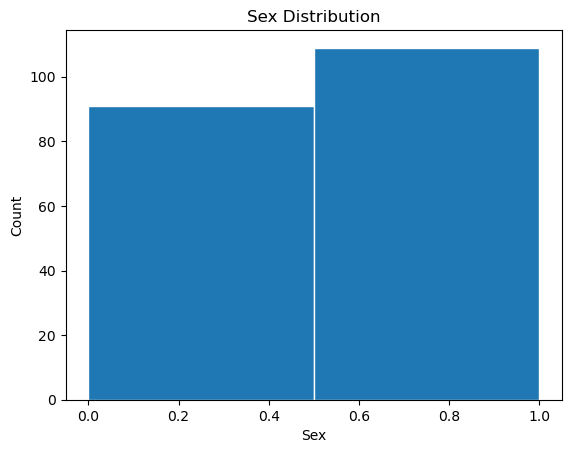

In [51]:
plt.hist(df['sex'],bins=2,edgecolor="white")
plt.title('Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

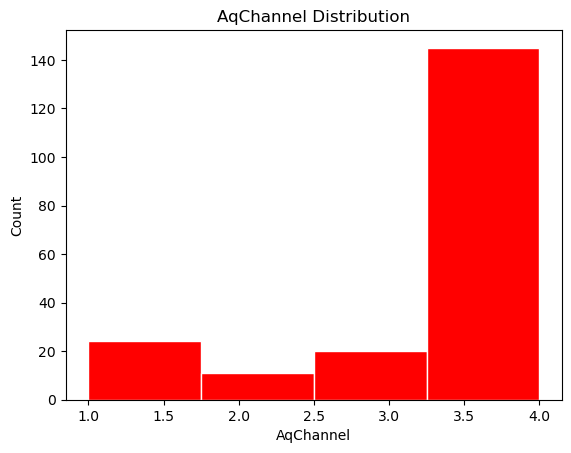

In [53]:
plt.hist(df['AqChannel'],bins=4,edgecolor="white",color="red")
plt.title('AqChannel Distribution')
plt.xlabel('AqChannel')
plt.ylabel('Count')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

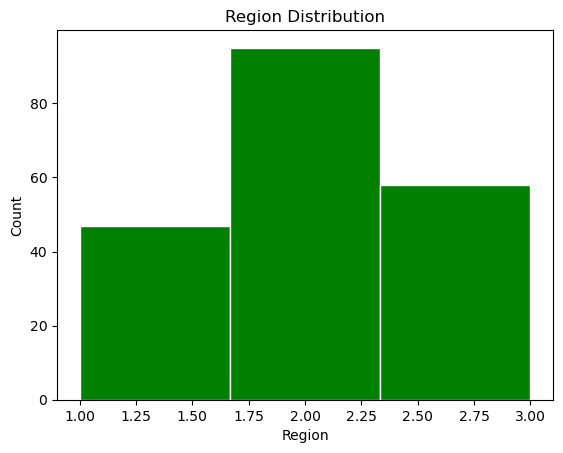

In [55]:
plt.hist(df['region'],bins=3,edgecolor="white",color="green")
plt.title('Region Distribution')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

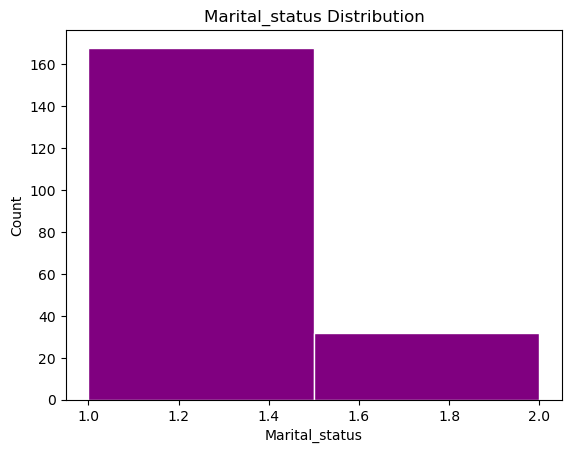

In [57]:
plt.hist(df['Marital_status'],bins=2,edgecolor="white",color="purple")
plt.title('Marital_status Distribution')
plt.xlabel('Marital_status')
plt.ylabel('Count')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

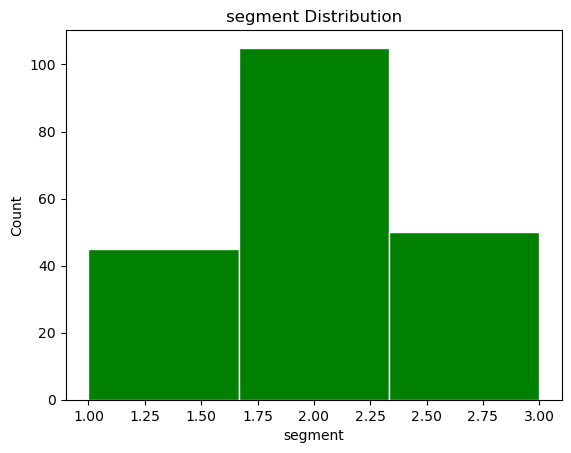

In [59]:
plt.hist(df['segment'],bins=3,edgecolor="white",color="green")
plt.title('segment Distribution')
plt.xlabel('segment')
plt.ylabel('Count')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

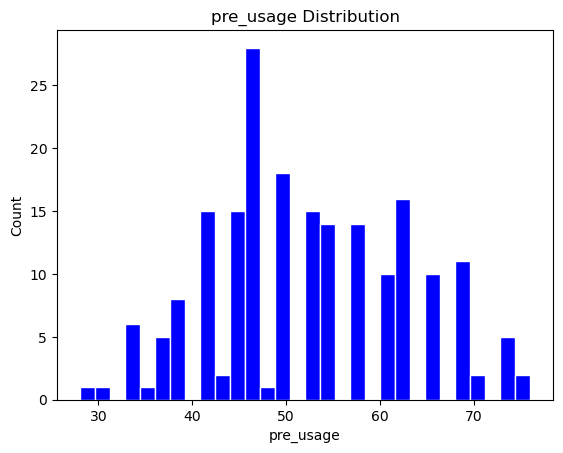

In [61]:
plt.hist(df['pre_usage'],bins=30,edgecolor="white",color="blue")
plt.title('pre_usage Distribution')
plt.xlabel('pre_usage')
plt.ylabel('Count')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

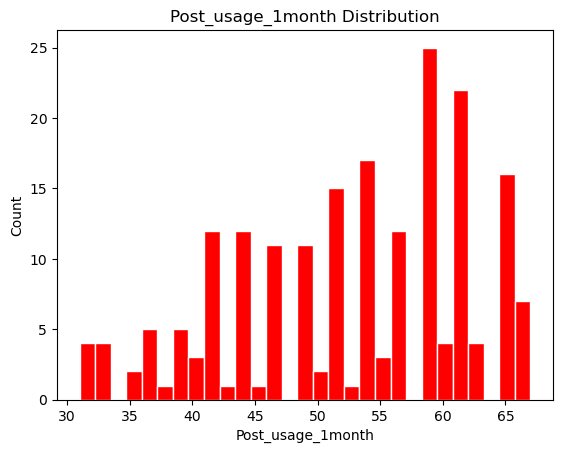

In [63]:
plt.hist(df['Post_usage_1month'],bins=29,edgecolor="white",color="red")
plt.title('Post_usage_1month Distribution')
plt.xlabel('Post_usage_1month')
plt.ylabel('Count')
plt.show

# Jawaban No. 2

## Penjelasan Umum
Pada bagian ini kita akan melakukan hipotesis untuk melihat apakah kampanye yang dilakukan berhasil. Untuk mendukung uji hipotesis ini kita menggunakan fungsi ttest_rel yang ada pada library SciPy.

## Perbandingan Sebelum dan 1 Bulan Setelah Kampanye
Pertama kita akan melakukan perbandingan penggunaan kartu kredit antara sebelum kampanye dengan 1 bulan setelah kampanye.
Perbandingan ini melibatkan dua kolom yaitu pre_usage (sebelum kampanye) dan kolom Post_usage_1month (1 bulan setelah kampanye).

Penentuan H0 dan H1 :
H0 (Hipotesis Null) : Rata-rata penggunaan sebelum kampanye (pre_usage) dan 1 bulan sesudah kampanye (Post_usage_1month) **SAMA alias KAMPANYE KARTU KREDIT TIDAK BERHASIL**
H1 (Hipotesis Alternatif) : Nilai rata-rata sebelum kampanye (pre_usage) dan Nilai rata-rata 1 bulan pasca kampanye (Post_usage_1month) **BERBEDA alias KAMPANYE KARTU KREDIT BERHASIL**  

In [69]:
print(df.pre_usage.mean()," <== rata-rata sebelum kampanye")
print(df.Post_usage_1month.mean()," <== rata-rata 1 bulan setelah kampanye")

52.23  <== rata-rata sebelum kampanye
52.775  <== rata-rata 1 bulan setelah kampanye


Nilai rata-rata sebelum kampanye dan rata-rata 1 bulan setelah kampanye nanti kita masukkan ke fungsi ttest_rel untuk pengujian hipotesis nol (dua sampel yang terkait atau berulang memiliki nilai rata-rata (yang diharapkan) yang identik).

In [72]:
stats.ttest_rel(a = df.pre_usage, b = df.Post_usage_1month)

TtestResult(statistic=-0.8673065458794775, pvalue=0.3868186820914985, df=199)

Karena pvalue 0.3868186820914985 kurang dari 0,05, maka kita gagal menolak H0 (Hipotesis Null). Oleh karena itu, KAMPANYE KARTU KREDIT BERHASIL.

## Perbandingan Sebelum dan 2 Bulan Setelah Kampanye
Perbandingan ini melibatkan dua kolom yaitu pre_usage yang berisi data-data sebelum kampanye dan kolom post_usage_2ndmonth yang berisi data-data 2 bulan setelah kampanye.

In [76]:
print(df.pre_usage.mean()," <== rata-rata sebelum kampanye")
print(df.post_usage_2ndmonth.mean()," <== rata-rata 2 bulan setelah kampanye")

52.23  <== rata-rata sebelum kampanye
58.0525  <== rata-rata 2 bulan setelah kampanye


Nilai rata-rata sebelum kampanye dan rata-rata 2 bulan setelah kampanye nanti kita masukkan ke fungsi ttest_rel untuk pengujian hipotesis nol (dua sampel yang terkait atau berulang memiliki nilai rata-rata (yang diharapkan) yang identik).

In [79]:
stats.ttest_rel(a = df.pre_usage, b = df.post_usage_2ndmonth)

TtestResult(statistic=-8.866832246938742, pvalue=4.295733828012836e-16, df=199)

Karena pvalue 4.295733828012836e-16 kurang dari 0,05, maka kita gagal menolak H0 (Hipotesis Null). Oleh karena itu, KAMPANYE KARTU KREDIT BERHASIL.